<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20cosmos004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

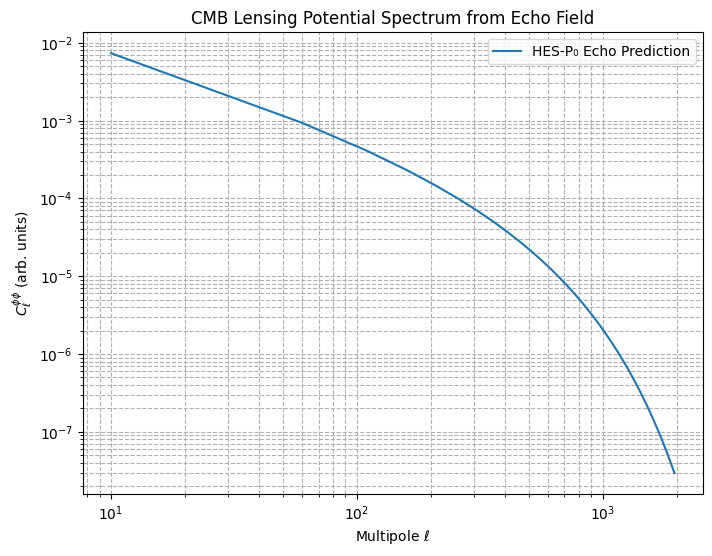

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Echo + neutrino parameters
lambda_0 = 1.166
sum_m_nu = 0.11   # eV
k_nu = 0.01 / sum_m_nu
chi_LS = 14000    # Mpc

# Echo potential spectrum
def P_phi(k):
    return np.exp(-k**2 * lambda_0**2 - k**2 / k_nu**2)

# Lensing potential spectrum
def C_phi_phi(ell):
    integrand = lambda chi: ((chi_LS - chi)/(chi*chi_LS))**2 * P_phi(ell/chi)
    return quad(integrand, 1, chi_LS)[0]

# Compute across multipoles
ells = np.arange(10, 2000, 50)
C_vals = [C_phi_phi(l) for l in ells]

# Plot
plt.figure(figsize=(8,6))
plt.loglog(ells, C_vals, label=r'HES-P₀ Echo Prediction')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell^{\phi\phi}$ (arb. units)')
plt.title('CMB Lensing Potential Spectrum from Echo Field')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()
